# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Sindi Prasetiyani
- **Email:** sindipras5@gmail.com
- **ID Dicoding:** CDCC414D6X1041
## Latar Belakang
Layanan bike sharing menjadi solusi transportasi ramah lingkungan. Untuk mengoptimalkan layanan, diperlukan pemahaman pola penggunaan berdasarkan waktu dan kondisi lingkungan.

## Menentukan Pertanyaan Bisnis

- Bagaimana pengaruh musim dan kondisi cuaca terhadap rata-rata jumlah peminjaman sepeda selama periode 2011–2012?

- Bagaimana pola penggunaan sepeda dalam satu hari, serta kapan waktu puncak penggunaan terjadi jika dibandingkan antara hari kerja (weekday) dan hari libur (weekend)?

## Import Semua Packages/Library yang Digunakan

In [10]:
import pandas as pd  # manipulasi data
import numpy as np   # operasi numerik
import matplotlib.pyplot as plt  # plotting dasar
import seaborn as sns  # visualisasi estetik
import os  # manajemen file/folder

# set tema visualisasi
sns.set_theme(style="whitegrid")

## Data Wrangling

### Gathering Data
Mengambil dataset harian dan per jam untuk dianalisis.

In [11]:
# membaca dataset harian
day_df = pd.read_csv("data/day.csv")

# membaca dataset per jam
hour_df = pd.read_csv("data/hour.csv")

# melihat 5 baris awal
display(day_df.head())
display(hour_df.head())

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Tersedia dua granularitas data: harian (ringkas) dan per jam (detail).
- Data per jam penting untuk analisis pola waktu (peak hour).

### Assessing Data
Memeriksa kualitas data: tipe data, missing value, dan duplikasi.

In [12]:
# struktur data
day_df.info()
hour_df.info()

# cek missing value
day_df.isna().sum()
hour_df.isna().sum()

# cek duplikasi
day_df.duplicated().sum()
hour_df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (tot

np.int64(0)

**Insight:**
- Dataset harian memiliki 731 entri, sedangkan dataset per jam memiliki 17.379 entri, menunjukkan perbedaan granularitas data.
- Tidak ditemukan missing value maupun data duplikat, sehingga kualitas data tergolong baik.
- Kolom `dteday` masih bertipe object dan perlu dikonversi ke datetime untuk analisis waktu.

- Kombinasi fitur numerik dan kategorikal memungkinkan analisis yang lebih komprehensif.

### Cleaning Data
Pada tahap ini dilakukan proses pembersihan dan penyesuaian data agar lebih siap untuk dianalisis.

In [13]:
# mengubah kolom tanggal ke format datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# mengganti nama kolom 'cnt' menjadi 'total_rentals'
day_df.rename(columns={'cnt': 'total_rentals'}, inplace=True)
hour_df.rename(columns={'cnt': 'total_rentals'}, inplace=True)

# membuat mapping kategori untuk season dan cuaca
# agar tidak lagi berupa angka (1,2,3,4) seperti revisi sebelumnya
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_map = {1: 'Clear', 2: 'Mist', 3: 'Light Rain/Snow', 4: 'Heavy Rain'}

# menerapkan mapping ke dataset
day_df['season'] = day_df['season'].map(season_map)
day_df['weathersit'] = day_df['weathersit'].map(weather_map)

hour_df['season'] = hour_df['season'].map(season_map)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_map)

**Insight:**
- Konversi kolom `dteday` ke `datetime` memungkinkan analisis berbasis waktu seperti tren harian maupun musiman.
- Perubahan nama kolom menjadi lebih deskriptif meningkatkan keterbacaan dan pemahaman data.
- Mapping kategori membuat data lebih interpretatif, sehingga hasil visualisasi dan analisis lebih mudah dipahami.

## Exploratory Data Analysis (EDA)
Pada tahap ini dilakukan analisis terhadap satu variabel, yaitu jumlah peminjaman sepeda `total_rentals` untuk memahami distribusi dan karakteristik dasarnya.

### Exploratory Data Analysis (EDA) – Univariate

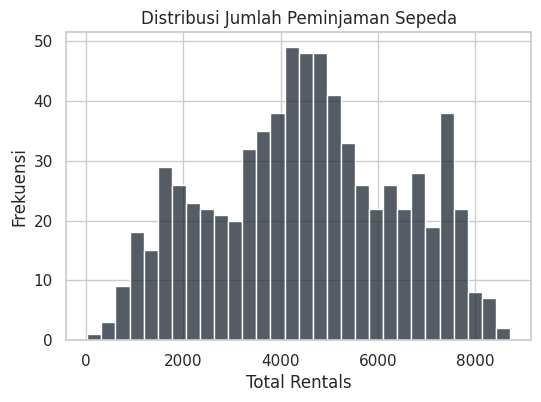

In [14]:
# melihat statistik deskriptif untuk memahami sebaran data
day_df['total_rentals'].describe()

# visualisasi distribusi untuk melihat pola penyebaran data
plt.figure(figsize=(6,4))
sns.histplot(
    day_df['total_rentals'],
    bins=30,
    color='#1B2631'
)

plt.title("Distribusi Jumlah Peminjaman Sepeda")
plt.xlabel("Total Rentals")
plt.ylabel("Frekuensi")
plt.show()

**Insight**
- Distribusi jumlah peminjaman menunjukkan variasi yang cukup tinggi antar hari.
- Terdapat indikasi bahwa tidak semua hari memiliki tingkat penggunaan yang sama, yang mengarah pada adanya faktor eksternal seperti cuaca atau musim.
- Pola distribusi dapat menjadi dasar untuk analisis lanjutan terkait faktor yang memengaruhi permintaan

### EDA – Analisis Kategorikal
Analisis ini bertujuan untuk melihat distribusi data berdasarkan kategori seperti musim dan kondisi cuaca.

In [15]:
# menghitung jumlah data pada tiap musim
day_df['season'].value_counts()

# menghitung jumlah data pada tiap kondisi cuaca
day_df['weathersit'].value_counts()

,count
weathersit,
Clear,463
Mist,247
Light Rain/Snow,21


**Insight**
- Mayoritas data berada pada kondisi cuaca Clear (463 data), diikuti oleh Mist (247 data), sedangkan kondisi Light Rain/Snow sangat sedikit (21 data).
- Distribusi ini menunjukkan bahwa sebagian besar observasi terjadi pada kondisi cuaca yang relatif baik, sehingga analisis kemungkinan akan lebih merepresentasikan perilaku pengguna pada kondisi normal.
- Minimnya data pada kondisi cuaca buruk dapat menyebabkan hasil analisis pada kategori tersebut kurang representatif dan perlu diinterpretasikan dengan hati-hati.

### EDA – Multivariate (Season & Weather)
Analisis ini dilakukan untuk melihat hubungan antara faktor lingkungan (musim dan cuaca) dengan jumlah peminjaman sepeda.

In [16]:
# rata-rata peminjaman berdasarkan musim
season_avg = day_df.groupby("season")["total_rentals"].mean().sort_values(ascending=False)
print(season_avg)

# rata-rata peminjaman berdasarkan kondisi cuaca
weather_avg = day_df.groupby("weathersit")["total_rentals"].mean().sort_values(ascending=False)
print(weather_avg)

season
Fall      5644.303191
Summer    4992.331522
Winter    4728.162921
Spring    2604.132597
Name: total_rentals, dtype: float64
weathersit
Clear              4876.786177
Mist               4035.862348
Light Rain/Snow    1803.285714
Name: total_rentals, dtype: float64


**Insight**
- Musim Fall memiliki rata-rata peminjaman tertinggi (5644), diikuti oleh Summer dan Winter, sedangkan Spring memiliki rata-rata paling rendah (2604).
- Hal ini menunjukkan bahwa penggunaan sepeda cenderung meningkat pada musim dengan kondisi cuaca yang lebih nyaman, dan menurun pada musim peralihan seperti Spring.
- Dari sisi cuaca, kondisi Clear menghasilkan rata-rata peminjaman tertinggi (4876), diikuti oleh Mist, sementara Light Rain/Snow memiliki nilai paling rendah (1803).
- Perbedaan ini mengindikasikan bahwa kondisi cuaca memiliki pengaruh signifikan terhadap keputusan pengguna dalam menggunakan sepeda.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh musim dan kondisi cuaca terhadap rata-rata jumlah peminjaman sepeda selama periode 2011–2012?

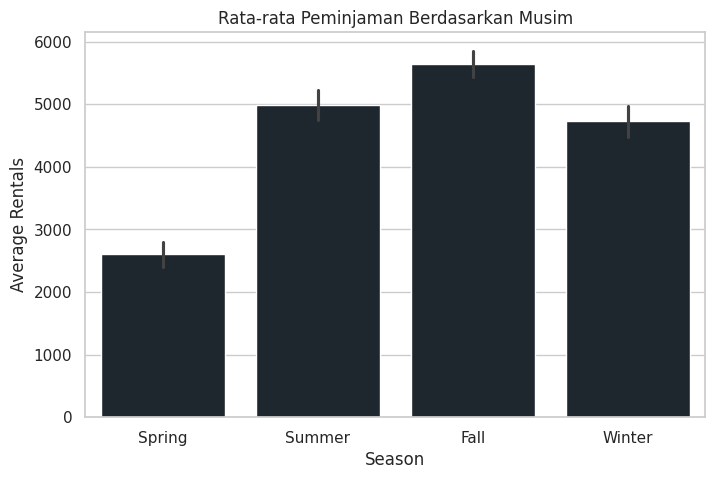

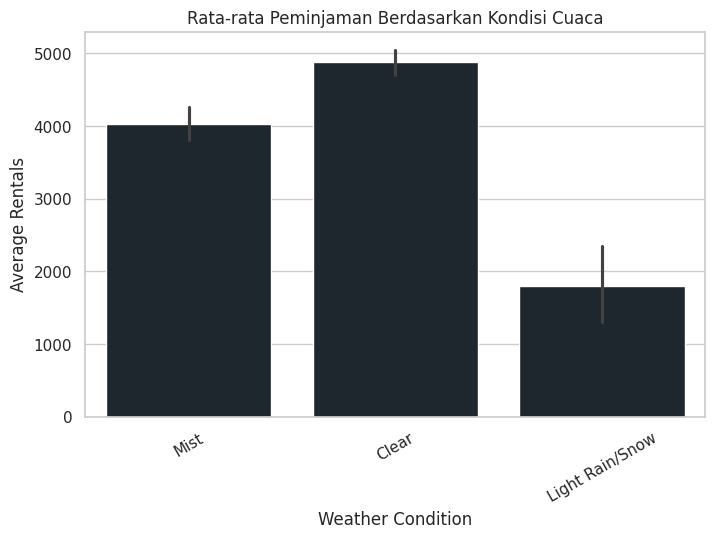

In [17]:
# visualisasi rata-rata peminjaman berdasarkan musim
plt.figure(figsize=(8,5))
sns.barplot(
    x='season',
    y='total_rentals',
    data=day_df,
    color='#1B2631'
)

plt.title("Rata-rata Peminjaman Berdasarkan Musim")
plt.xlabel("Season")
plt.ylabel("Average Rentals")
plt.show()


# visualisasi rata-rata peminjaman berdasarkan kondisi cuaca
plt.figure(figsize=(8,5))
sns.barplot(
    x='weathersit',
    y='total_rentals',
    data=day_df,
    color='#1B2631'
)

plt.title("Rata-rata Peminjaman Berdasarkan Kondisi Cuaca")
plt.xlabel("Weather Condition")
plt.ylabel("Average Rentals")

plt.xticks(rotation=30)
plt.show()

**Insight:**
- Rata-rata peminjaman sepeda tertinggi terjadi pada musim Fall, diikuti oleh Summer, kemudian Winter, dan paling rendah pada Spring. Hal ini menunjukkan bahwa musim dengan kondisi lingkungan yang lebih nyaman cenderung meningkatkan penggunaan sepeda.
- Dari sisi cuaca, kondisi Clear menghasilkan rata-rata peminjaman tertinggi, diikuti oleh Mist, sedangkan Light Rain/Snow memiliki nilai paling rendah. Ini mengindikasikan bahwa kondisi cuaca buruk secara signifikan menurunkan minat pengguna.
- Perbedaan yang cukup jauh antara kondisi cuaca terbaik dan terburuk menunjukkan bahwa faktor cuaca memiliki pengaruh yang lebih kuat dibandingkan variasi antar musim.
Secara keseluruhan, faktor lingkungan seperti musim dan cuaca terbukti menjadi determinan utama dalam pola penggunaan layanan bike sharing.

### Pertanyaan 2:Bagaimana pola penggunaan sepeda dalam satu hari, serta kapan waktu puncak penggunaan terjadi jika dibandingkan antara hari kerja (weekday) dan hari libur (weekend)?

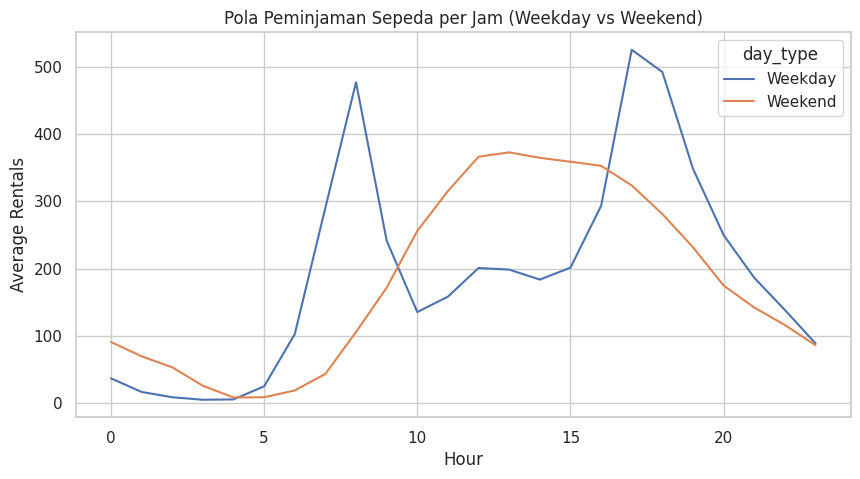

In [18]:
# membuat kolom kategori hari (weekday vs weekend)
hour_df['day_type'] = hour_df['workingday'].map({
    1: 'Weekday',
    0: 'Weekend'
})

# menghitung rata-rata peminjaman per jam
hourly_pattern = hour_df.groupby(['hr','day_type'])['total_rentals'].mean().reset_index()

# visualisasi pola penggunaan
plt.figure(figsize=(10,5))
sns.lineplot(
    data=hourly_pattern,
    x='hr',
    y='total_rentals',
    hue='day_type'
)

plt.title("Pola Peminjaman Sepeda per Jam (Weekday vs Weekend)")
plt.xlabel("Hour")
plt.ylabel("Average Rentals")
plt.show()

**Insight:**
- Pada hari kerja (weekday), terdapat dua puncak penggunaan yang jelas, yaitu sekitar pukul 08.00 dan 17.00–18.00, yang menunjukkan pola penggunaan sepeda untuk aktivitas commuting (berangkat dan pulang kerja).
- Pada hari libur (weekend), pola penggunaan cenderung lebih merata sepanjang siang hari (sekitar 11.00–15.00) tanpa lonjakan tajam, yang mengindikasikan penggunaan lebih bersifat rekreasi.
- Perbedaan pola ini menunjukkan bahwa tujuan penggunaan sepeda berbeda antara weekday dan weekend, di mana weekday lebih terstruktur (rutinitas), sedangkan weekend lebih fleksibel.
- Secara keseluruhan, waktu puncak penggunaan pada weekday lebih tinggi dibandingkan weekend, yang menandakan permintaan lebih besar pada jam sibuk hari kerja.

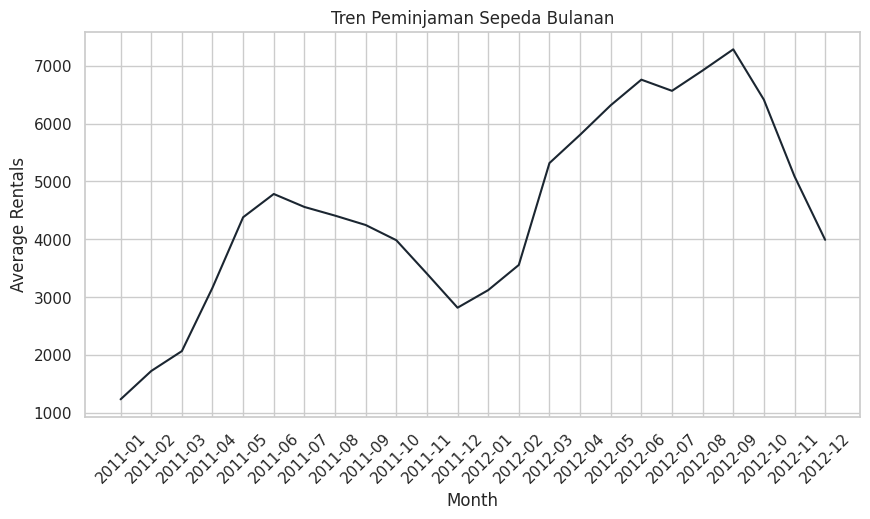

In [23]:
# membuat kolom bulan
day_df['month_year'] = day_df['dteday'].dt.to_period('M')

# agregasi rata-rata peminjaman per bulan
monthly_trend = day_df.groupby('month_year')['total_rentals'].mean().reset_index()

# ubah ke datetime biar bisa diplot
monthly_trend['month_year'] = monthly_trend['month_year'].astype(str)

# visualisasi tren bulanan
plt.figure(figsize=(10,5))

sns.lineplot(
    data=monthly_trend,
    x='month_year',
    y='total_rentals',
    color='#1B2631'
)

plt.title("Tren Peminjaman Sepeda Bulanan")
plt.xlabel("Month")
plt.ylabel("Average Rentals")

plt.xticks(rotation=45)
plt.show()

**Insight**
- Terlihat adanya pola musiman yang jelas, di mana jumlah peminjaman meningkat dari awal tahun dan mencapai puncak di pertengahan hingga akhir tahun (sekitar Juni–September).
- Puncak tertinggi terjadi pada tahun 2012 sekitar bulan Agustus–September, yang menunjukkan peningkatan penggunaan dibanding tahun sebelumnya.
Setelah mencapai puncak, terjadi penurunan tajam di akhir tahun (November–Desember), yang kemungkinan dipengaruhi oleh perubahan musim atau kondisi cuaca.
- Jika dibandingkan antar tahun, tren tahun 2012 lebih tinggi dibandingkan 2011, yang mengindikasikan adanya pertumbuhan penggunaan layanan bike sharing dari waktu ke waktu.

## Analisis Lanjutan (Opsional)
Pada tahap ini dilakukan analisis lanjutan untuk memperdalam pemahaman terhadap pola penggunaan sepeda dengan menggunakan teknik clustering sederhana (binning & manual grouping) tanpa algoritma machine learning.

In [19]:
# Binning
# membagi data ke dalam 3 kategori berdasarkan jumlah peminjaman
# q=3 artinya dibagi menjadi 3 kelompok (Low, Medium, High)
hour_df['usage_level'] = pd.qcut(
    hour_df['total_rentals'],
    q=3,
    labels=['Low','Medium','High']
)

# melihat jumlah data pada tiap kategori
hour_df['usage_level'].value_counts()

,count
usage_level,
Medium,5823
Low,5797
High,5759


**Insight:**
- Data terbagi relatif seimbang ke dalam tiga kategori (Low, Medium, High), masing-masing sekitar 5.7k–5.8k data, yang menunjukkan distribusi penggunaan yang merata.
- Hal ini mengindikasikan bahwa tidak ada dominasi ekstrem pada satu tingkat penggunaan tertentu, sehingga sistem memiliki variasi permintaan yang stabil.
- Kategori High dapat merepresentasikan kondisi atau waktu dengan permintaan tertinggi, yang penting untuk perencanaan operasional.

In [20]:
#  Manual Grouping
# membuat fungsi untuk mengelompokkan jam ke dalam kategori waktu
def categorize_hour(hr):
    if 6 <= hr < 12:
        return "Morning"
    elif 12 <= hr < 18:
        return "Afternoon"
    else:
        return "Night"

# menerapkan fungsi ke kolom hr
hour_df['time_category'] = hour_df['hr'].apply(categorize_hour)

# menghitung rata-rata peminjaman per kategori waktu
hour_df.groupby('time_category')['total_rentals'].mean()

,total_rentals
time_category,
Afternoon,295.483886
Morning,208.100688
Night,126.401897


**Insight:**
- Kategori Afternoon memiliki rata-rata peminjaman tertinggi (295), diikuti oleh Morning (208), dan terendah pada Night (126).
- Hal ini menunjukkan bahwa aktivitas pengguna paling tinggi terjadi pada siang hingga sore hari, yang berkaitan dengan aktivitas harian.
- Penggunaan yang lebih rendah pada malam hari mengindikasikan bahwa sepeda lebih banyak digunakan saat kondisi aktivitas masih aktif (siang hari).

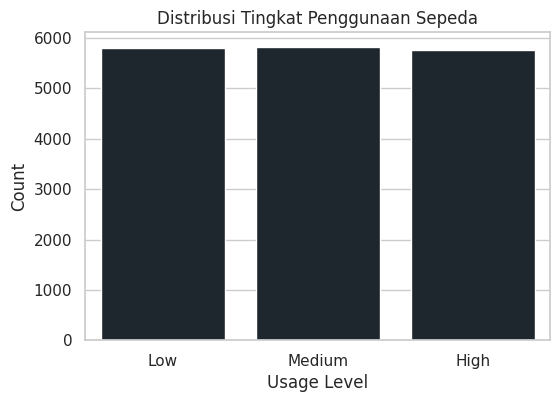

In [21]:
# Visualisasi Segmentasi
# Visualisasi jumlah data pada tiap kategori penggunaan
plt.figure(figsize=(6,4))

sns.countplot(
    x='usage_level',
    data=hour_df,
    color='#1B2631'
)

plt.title("Distribusi Tingkat Penggunaan Sepeda")
plt.xlabel("Usage Level")
plt.ylabel("Count")

plt.show()

**Insight:**
- Distribusi jumlah data pada kategori Low, Medium, dan High terlihat hampir sama, yang memperkuat bahwa pembagian binning berhasil menghasilkan segmentasi yang seimbang.
- Hal ini menunjukkan bahwa dataset memiliki variasi penggunaan yang merata, tidak condong pada satu kategori tertentu.
- Visualisasi ini membantu dalam memahami persebaran tingkat penggunaan secara keseluruhan dengan lebih intuitif.

## Conclusion

- Bagaimana pengaruh musim dan kondisi cuaca terhadap rata-rata jumlah peminjaman sepeda selama periode 2011–2012?

**Jawaban (Insight):**
Musim Fall dan Summer menunjukkan rata-rata peminjaman tertinggi, sedangkan Spring memiliki nilai terendah, yang menunjukkan adanya pengaruh kondisi musiman terhadap penggunaan sepeda.
Kondisi cuaca Clear menghasilkan jumlah peminjaman tertinggi, sementara Light Rain/Snow secara signifikan menurunkan jumlah penggunaan.
Hal ini menunjukkan bahwa faktor lingkungan seperti musim dan cuaca merupakan determinan utama dalam tingkat penggunaan layanan bike sharing.

**Rekomendasi:**
Meningkatkan ketersediaan sepeda pada musim dengan permintaan tinggi (Summer & Fall).
Mengoptimalkan operasional saat kondisi cuaca cerah untuk memaksimalkan penggunaan.
Menyusun strategi mitigasi atau promosi khusus saat cuaca buruk untuk menjaga tingkat penggunaan.
- Bagaimana pola penggunaan sepeda dalam satu hari, serta kapan waktu puncak penggunaan terjadi jika dibandingkan antara hari kerja (weekday) dan hari libur (weekend)?

**Jawaban (Insight):**
Pada hari kerja (weekday), terdapat dua puncak penggunaan utama yaitu pada pagi (sekitar pukul 08.00) dan sore (17.00–18.00), yang menunjukkan pola aktivitas commuting.
Pada hari libur (weekend), pola penggunaan lebih merata sepanjang hari tanpa lonjakan tajam, yang mengindikasikan penggunaan untuk aktivitas rekreasi.
Tingkat penggunaan pada weekday cenderung lebih tinggi pada jam-jam tertentu dibandingkan weekend, menunjukkan perbedaan tujuan penggunaan.

**Rekomendasi:**
Menambah distribusi sepeda pada jam sibuk (pagi dan sore hari) khususnya pada hari kerja.
Mengoptimalkan pemeliharaan atau redistribusi sepeda di luar jam sibuk untuk menjaga ketersediaan.
Mengembangkan program atau promosi untuk meningkatkan penggunaan pada akhir pekan.

In [22]:
os.makedirs("dashboard", exist_ok=True)

hour_df.to_csv("dashboard/main_data.csv", index=False)

print("✅ main_data.csv berhasil dibuat!")

✅ main_data.csv berhasil dibuat!
